# Visión por Computadora 2025
## Lab 03 


In [2]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import cv2

### Ejercicio 1

In [3]:
def image_rgb_to_bw(image_path, k=1):
  # Conversión de RGB a escala de grises
  image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  
  if image_gray is None:
    raise FileNotFoundError(f"Image not found at path: {image_path}")
  
  # Reescalado (resize) a un tamaño (128k, 64k), (ratio 2:1)
  new_size = (64 * k, 128 * k)
  image_gray = cv2.resize(image_gray, new_size)
  
  # Convertir a numpy array en formato 8 bits o float
  image_array = np.asarray(image_gray, dtype=np.float32 if image_gray.dtype == np.float32 else np.uint8)
  return image_array


Converting image to black and white


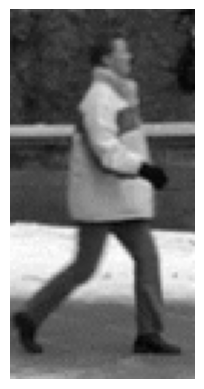

In [4]:

# Read image from input/person.png
image_path = "input/person.png"

# Convert to black and white
image_bw = image_rgb_to_bw(image_path)

print("Converting image to black and white")

# Display the black and white image
plt.imshow(image_bw, cmap='gray')
plt.axis('off')  # Turn off axis
plt.show()


### Ejercicio 2

In [5]:
def compute_gradient(image_path, method='sobel'):
    # Load image

    img = image_rgb_to_bw(image_path)
    
    # Define filters
    if method == 'prewitt':
        kernel_x = np.array([[-1, -1, -1],
                             [ 0,  0,  0],
                             [ 1,  1,  1]])
        
        kernel_y = np.array([[-1,  0,  1],
                             [-1,  0,  1],
                             [-1,  0,  1]])
        
    else:  # Método por defecto: Sobel
        kernel_x = np.array([[-1, -2, -1],
                             [ 0,  0,  0],
                             [ 1,  2,  1]])
    
        kernel_y = np.array([[-1,  0,  1],
                             [-2,  0,  2],
                             [-1,  0,  1]])

    print(f"\n Utilizando el método de {method} \n")

    # Aplicar filtros
    Gx = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_x)
    Gy = cv2.filter2D(img.astype(np.float32), cv2.CV_32F, kernel_y)
    
    # Calcular magnitud y ángulo del gradiente
    magnitude = np.sqrt(Gx**2 + Gy**2)
    angle = np.arctan2(-Gy, Gx) * (180 / np.pi) % 180  # Convertir a grados y hacer módulo 180
    
    return magnitude, angle


 Utilizando el método de prewitt 



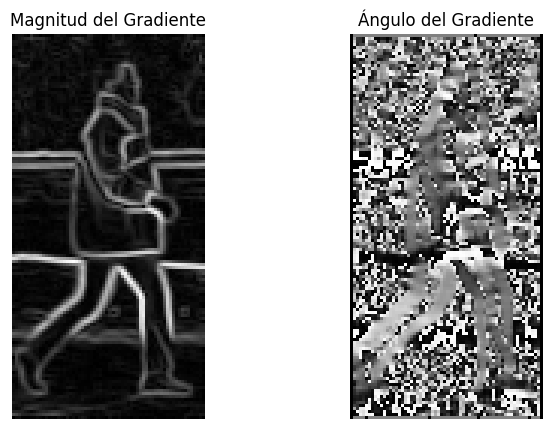

In [33]:
magnitude, angle = compute_gradient(image_path, method='prewitt')

# Mostrar resultados
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitud del Gradiente')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angle, cmap='gray')
plt.title('Ángulo del Gradiente')
plt.axis('off')

plt.show()



 Utilizando el método de sobel 



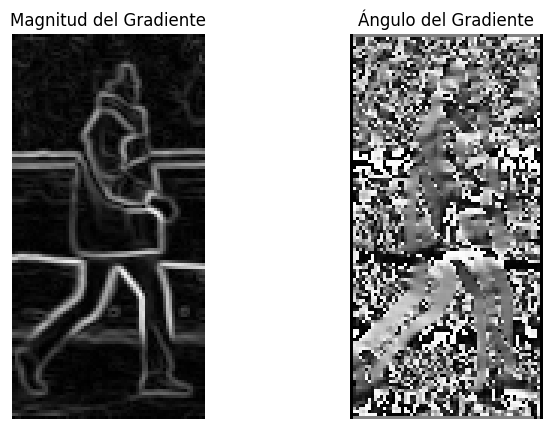

In [34]:
magnitude, angle = compute_gradient(image_path, method='sobel')

# Mostrar resultados
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Magnitud del Gradiente')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angle, cmap='gray')
plt.title('Ángulo del Gradiente')
plt.axis('off')

plt.show()



### Ejercicio 3

In [8]:
def build_block_stacks(magnitude, angle, block_size):
    stride = block_size // 2
    height, width = magnitude.shape

    magnitude_blocks = []
    angle_blocks = []

    for y in range(0, height - block_size + 1, stride):
        for x in range(0, width - block_size + 1, stride):
            magnitude_block = magnitude[y:y + block_size, x:x + block_size]
            angle_block = angle[y:y + block_size, x:x + block_size]
            magnitude_blocks.append(magnitude_block)
            angle_blocks.append(angle_block)

    magnitude_stack = np.array(magnitude_blocks)
    angle_stack = np.array(angle_blocks)

    M = (height - block_size) // stride + 1
    N = (width - block_size) // stride + 1

    print(f"Shape of magnitude stack: {magnitude_stack.shape}")
    print(f"Shape of angle stack: {angle_stack.shape}")
    print(f"M: {M}, N: {N}")

    return magnitude_stack, angle_stack


In [9]:
magnitude, angle = compute_gradient(image_path)
block_size = 8  # Example block size, should be a multiple of 4
magnitude_stack, angle_stack = build_block_stacks(magnitude, angle, block_size)


 Utilizando el método de sobel 

Shape of magnitude stack: (465, 8, 8)
Shape of angle stack: (465, 8, 8)
M: 31, N: 15


### Ejercicio 4

In [77]:
def compute_hog(magnitude_stack, angle_stack, num_bins=9):
    num_blocks = magnitude_stack.shape[0]
    hog_features = []
    
    # Bin edges for the histogram (0 to 180 degrees)
    bin_size = 180 / num_bins
    bin_edges = np.arange(0, 180 + bin_size, bin_size)
    
    for i in range(num_blocks):
        block_magnitude = magnitude_stack[i]
        block_angle = angle_stack[i]
        
        # Initialize histogram
        histogram = np.zeros(num_bins)
        
        # Create histogram for the block
        for bin_idx in range(num_bins):
            # Define bin range
            low = bin_edges[bin_idx]
            high = bin_edges[bin_idx + 1]
            
            # Find pixels with angles in this bin range
            if bin_idx < num_bins - 1:
                mask = (block_angle >= low) & (block_angle < high)
            else:
                # Handle last bin inclusive of the upper bound
                mask = (block_angle >= low) & (block_angle <= high)
                
            # Sum the magnitudes for this bin
            histogram[bin_idx] = np.sum(block_magnitude[mask])
        
        # Normalize the histogram
        norm = np.sqrt(np.sum(histogram ** 2) + 1e-7)  # Add small value to avoid division by zero
        normalized_histogram = histogram / norm if norm > 0 else histogram
        
        hog_features.append(normalized_histogram)
    
    # Convert to numpy array
    hog_features = np.array(hog_features)
    
    return hog_features




In [36]:
block_size = 8
stride = 8
hog_features = compute_hog(magnitude_stack, angle_stack)
print(f"Shape of HOG features: {hog_features.shape}")

Shape of HOG features: (465, 9)


### Ejercicio 5

In [76]:
def visualize_hog_direction_image(hog_features, image_height, image_width, block_size, num_bins=9):
    
    # Calculate number of blocks in height and width
    stride = block_size // 2
    blocks_height = (image_height - block_size) // stride + 1
    blocks_width = (image_width - block_size) // stride + 1
    
    # Create an empty image
    direction_image = np.zeros((image_height, image_width, 3), dtype=np.uint8)
    
    # Calculate center points for each block
    block_idx = 0
    bin_angles = np.linspace(0, 180, num_bins, endpoint=False) + (180 / (2 * num_bins))  # Center of each bin
    
    for y in range(0, blocks_height):
        for x in range(0, blocks_width):
            # Calculate block center coordinates
            center_y = y * stride + block_size // 2
            center_x = x * stride + block_size // 2
            
            if block_idx < len(hog_features):
                # Get the dominant orientation (bin with highest value)
                histogram = hog_features[block_idx]
                dominant_bin = np.argmax(histogram)
                dominant_angle = bin_angles[dominant_bin]
                strength = np.max(histogram) * 255  # Scale for visibility
                
                # Convert angle to radians for line calculation
                angle_rad = np.deg2rad(dominant_angle)
                
                # Calculate line endpoints
                line_length = block_size // 2
                x1 = int(center_x - line_length * np.cos(angle_rad))
                y1 = int(center_y - line_length * np.sin(angle_rad))
                x2 = int(center_x + line_length * np.cos(angle_rad))
                y2 = int(center_y + line_length * np.sin(angle_rad))
                
                # Draw line representing dominant direction
                cv2.line(direction_image, (x1, y1), (x2, y2), (0, int(strength), int(255-strength)), 1)
                
                block_idx += 1
    
    return direction_image


In [74]:
stride = 8
block_size = 8
magnitude_stack, angle_stack = build_block_stacks(magnitude, angle, block_size)
hog_features = compute_hog(magnitude_stack, angle_stack)

# Assuming the original image dimensions were used to create the blocks
original_image = image_bw

if original_image is not None:
    image_height, image_width = original_image.shape[:2]
    direction_image = visualize_hog_direction_image(hog_features, image_height, image_width, block_size)


else:
    print("Could not load the image to get its dimensions.")


Shape of magnitude stack: (465, 8, 8)
Shape of angle stack: (465, 8, 8)
M: 31, N: 15


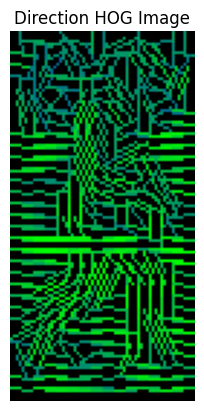

In [75]:

plt.imshow(direction_image, cmap='grey') # You can change 'gray' to other colormaps

# Turn off axis labels and ticks (optional)
plt.axis('off')

# Show the image
plt.title("Direction HOG Image")
plt.show()

### Ejercicio 6

In [85]:
I = image_bw
I

array([[ 69,  75,  75, ...,  35,  28,  34],
       [ 82,  66,  64, ...,  28,  22,  37],
       [ 78,  66,  65, ...,  58,  42,  48],
       ...,
       [130, 131, 137, ..., 120, 125, 119],
       [160, 160, 155, ..., 121, 126, 128],
       [186, 186, 168, ..., 135, 135, 142]], shape=(128, 64), dtype=uint8)

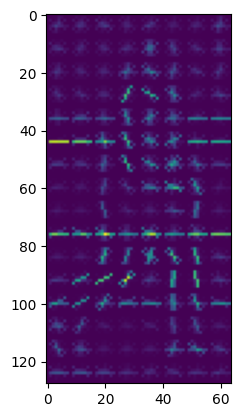

In [41]:
from skimage.feature import hog
fd, hogI = hog(I, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
plt.figure()
plt.imshow(hogI)
plt.show()

### Ejercicio 7

In [86]:
hog2 = cv2.HOGDescriptor()
hog2.setSVMDetector(cv2.HOGDescriptor.getDefaultPeopleDetector())
locations, confidence = hog2.detectMultiScale(I)
for (x, y, w, h) in locations:
    cv2.rectangle(I, (x, y), (x + w, y + h), (0, 0, 255), 5)
    I_rgb = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20,10))
    plt.imshow(I_rgb)
    plt.axis('off')
    plt.show()

In [89]:
I

array([[ 69,  75,  75, ...,  35,  28,  34],
       [ 82,  66,  64, ...,  28,  22,  37],
       [ 78,  66,  65, ...,  58,  42,  48],
       ...,
       [130, 131, 137, ..., 120, 125, 119],
       [160, 160, 155, ..., 121, 126, 128],
       [186, 186, 168, ..., 135, 135, 142]], shape=(128, 64), dtype=uint8)

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_people(image_path=None, image=None, visualization=True, confidence_threshold=0.5):
    if image is None and image_path is not None:
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"No se pudo cargar la imagen desde {image_path}")
    elif image is None:
        raise ValueError("Debe proporcionar una imagen o una ruta de imagen")
    
    # Crear una copia para dibujar los resultados
    image_with_detections = image.copy()
    
    # Inicializar el detector HOG
    hog = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    
    # Detectar personas en la imagen
    locations, confidence_scores = hog.detectMultiScale(
        image, 
        winStride=(8, 8),
        padding=(16, 16), 
        scale=1.05,
        useMeanshiftGrouping=False
    )
    
    # Filtrar por umbral de confianza
    if len(locations) > 0:
        filtered_indices = [i for i, conf in enumerate(confidence_scores) if conf >= confidence_threshold]
        locations = locations[filtered_indices]
        confidence_scores = confidence_scores[filtered_indices]
    
    # Dibujar rectángulos en las ubicaciones detectadas
    for i, (x, y, w, h) in enumerate(locations):
        # Dibujar rectángulo
        cv2.rectangle(image_with_detections, (x, y), (x + w, y + h), (0, 0, 255), 3)
        
        # Añadir etiqueta con puntuación de confianza
        conf_text = f"{confidence_scores[i]:.2f}"
        cv2.putText(image_with_detections, conf_text, (x, y-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
    
    # Mostrar resultados
    if visualization:
        plt.figure(figsize=(12, 8))
        # Convertir de BGR a RGB para mostrar con matplotlib
        rgb_image = cv2.cvtColor(image_with_detections, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_image)
        plt.title(f"Detección de personas: {len(locations)} encontradas")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return image_with_detections, locations, confidence_scores


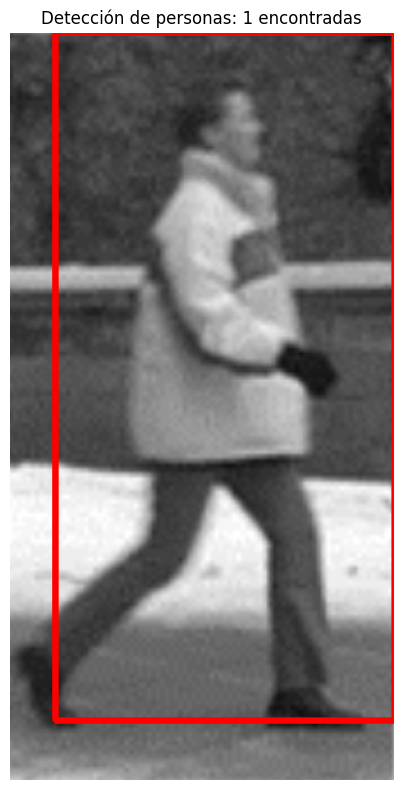

(array([[[ 98,  98,  98],
         [101, 101, 101],
         [105, 105, 105],
         ...,
         [  0,   0, 255],
         [  0,   0, 255],
         [  0,   0, 255]],
 
        [[ 77,  77,  77],
         [ 81,  81,  81],
         [ 85,  85,  85],
         ...,
         [  0,   0, 255],
         [  0,   0, 255],
         [  0,   0, 255]],
 
        [[ 56,  56,  56],
         [ 61,  61,  61],
         [ 65,  65,  65],
         ...,
         [  0,   0, 255],
         [  0,   0, 255],
         [  0,   0, 255]],
 
        ...,
 
        [[185, 185, 185],
         [185, 185, 185],
         [185, 185, 185],
         ...,
         [139, 139, 139],
         [153, 153, 153],
         [170, 170, 170]],
 
        [[191, 191, 191],
         [191, 191, 191],
         [191, 191, 191],
         ...,
         [144, 144, 144],
         [157, 157, 157],
         [172, 172, 172]],
 
        [[200, 200, 200],
         [200, 200, 200],
         [200, 200, 200],
         ...,
         [153, 153, 153],
  

In [115]:
detect_people(image_path="input/person.png", confidence_threshold=0.5)

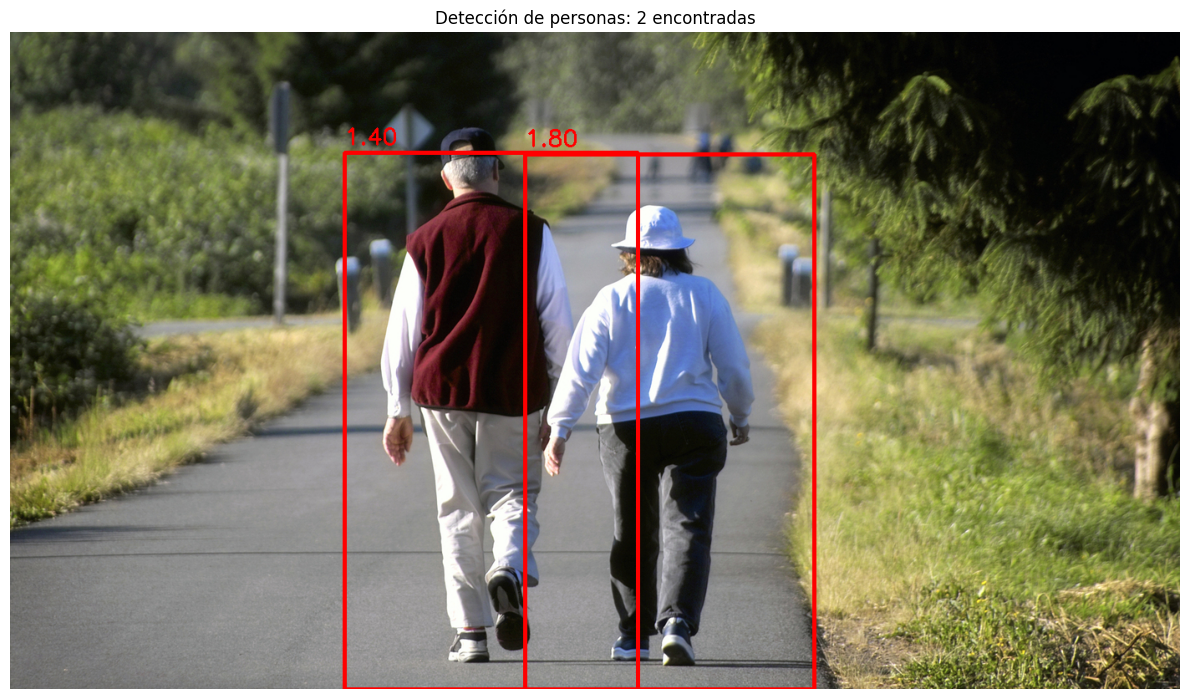

(array([[[ 58,  82,  72],
         [ 57,  81,  71],
         [ 61,  86,  76],
         ...,
         [  4,   2,   1],
         [  4,   2,   1],
         [  4,   2,   1]],
 
        [[ 59,  83,  71],
         [ 61,  86,  76],
         [ 65,  89,  79],
         ...,
         [  4,   2,   1],
         [  4,   2,   1],
         [  4,   2,   1]],
 
        [[ 61,  85,  75],
         [ 62,  87,  77],
         [ 68,  92,  82],
         ...,
         [  4,   2,   1],
         [  4,   2,   1],
         [  4,   2,   1]],
 
        ...,
 
        [[100, 102, 103],
         [110, 112, 113],
         [116, 116, 116],
         ...,
         [ 48,  66,  73],
         [ 65,  92, 102],
         [ 43,  67,  79]],
 
        [[ 99, 104, 103],
         [105, 110, 108],
         [102, 104, 104],
         ...,
         [ 43,  65,  70],
         [ 52,  80,  87],
         [ 36,  54,  65]],
 
        [[ 98, 103, 102],
         [ 92,  99,  96],
         [ 93,  98,  97],
         ...,
         [ 34,  48,  54],
  

In [116]:
detect_people(image_path="input/olds.jpg", confidence_threshold=1)

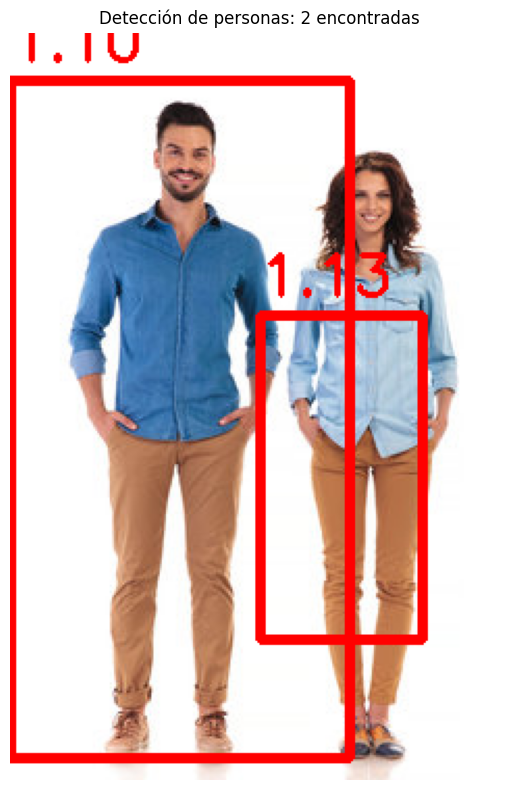

(array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
  

In [10]:
detect_people(image_path="input/image.png", confidence_threshold=1)